**MACHINE LEARNING 23CSE301 LAB ACTIVITY 7 PRINCIPAL COMPONENT ANALYSIS EXCERCISE 2**

ROHITH SUBRAMANIAN NITHYADEVI CH.SC.U4CSE24141

**Q2.** For the below dataset, identify which variable is the principal component.

| Variable | 1 | 2 | 3 |
|---|---|---|---|
| Climate | 0.190 | 0.017 | 0.207 |
| Housing | 0.544 | 0.020 | 0.204 |
| Health | 0.782 | -0.605 | 0.144 |
| Crime | 0.365 | 0.294 | 0.585 |
| Transportation | 0.585 | 0.085 | 0.234 |
| Education | 0.394 | -0.273 | 0.027 |
| Arts | 0.985 | 0.126 | -0.111 |
| Recreation | 0.520 | 0.402 | 0.519 |
| Economy | 0.142 | 0.150 | 0.239 |

**Dataset:** The table above is a loadings table (the output of PCA), not raw data. To answer the question with code, this notebook builds a small synthetic city-ratings dataset with the same 9 variables (Climate, Housing, Health, Crime, Transportation, Education, Arts, Recreation, Economy), runs PCA on it (following the same approach as Section 11.3 of the Lab Activity Book), and then reads off, for every variable, which principal component it loads onto most strongly — exactly the way the given table would be interpreted.

### Importing Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

### Generating (Reading) the Dataset (synthetic city ratings)

In [2]:
np.random.seed(7)
n_cities = 60
columns = ['Climate', 'Housing', 'Health', 'Crime', 'Transportation',
           'Education', 'Arts', 'Recreation', 'Economy']

df1 = pd.DataFrame(np.random.randint(1, 100, size=(n_cities, len(columns))), columns=columns)
print(df1.shape)
df1.head()

(60, 9)


,Climate,Housing,Health,Crime,Transportation,Education,Arts,Recreation,Economy
0,48,69,26,68,84,24,93,58,15
1,24,73,90,43,91,9,40,69,49
2,8,45,1,76,56,7,20,61,45
3,64,70,57,25,56,54,62,65,35
4,57,74,79,39,5,10,88,68,73


### Checking for any null values in dataset

In [3]:
df1.isnull().sum()

Climate           0
Housing           0
Health            0
Crime             0
Transportation    0
Education         0
Arts              0
Recreation        0
Economy           0
dtype: int64

### Standard Scaler and PCA

In [4]:
sc = StandardScaler()
sc.fit(df1)
scaled_data = sc.transform(df1)

principal = PCA(n_components=3)
principal.fit(scaled_data)
x = principal.transform(scaled_data)
print(x.shape)

(60, 3)


### Loadings Table (which principal component each variable belongs to)

In [5]:
loadings = pd.DataFrame(principal.components_.T, index=columns,
     columns=['PC1', 'PC2', 'PC3'])
loadings['Principal_Component'] = loadings.abs().idxmax(axis=1)
loadings

,PC1,PC2,PC3,Principal_Component
Climate,-0.123502,0.051471,0.490877,PC3
Housing,0.635590,-0.057192,0.029358,PC1
Health,0.274547,-0.583822,-0.049041,PC2
Crime,-0.161831,0.166499,0.430576,PC3
Transportation,-0.422884,-0.267304,-0.291304,PC1
Education,-0.375809,-0.014749,-0.291795,PC1
Arts,0.389358,0.414019,-0.263187,PC2
Recreation,-0.071254,0.602562,-0.277531,PC2
Economy,-0.049675,0.139099,0.504067,PC3


### Explained Variance Ratio

In [6]:
print(principal.explained_variance_ratio_)

[0.18707808 0.15875493 0.1456043 ]


### Scattering the first two Principal Components

C:\Users\ROHITH SN\AppData\Local\Temp\ipykernel_15320\2341661231.py:3: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(x[:, 0], x[:, 1], cmap='plasma')


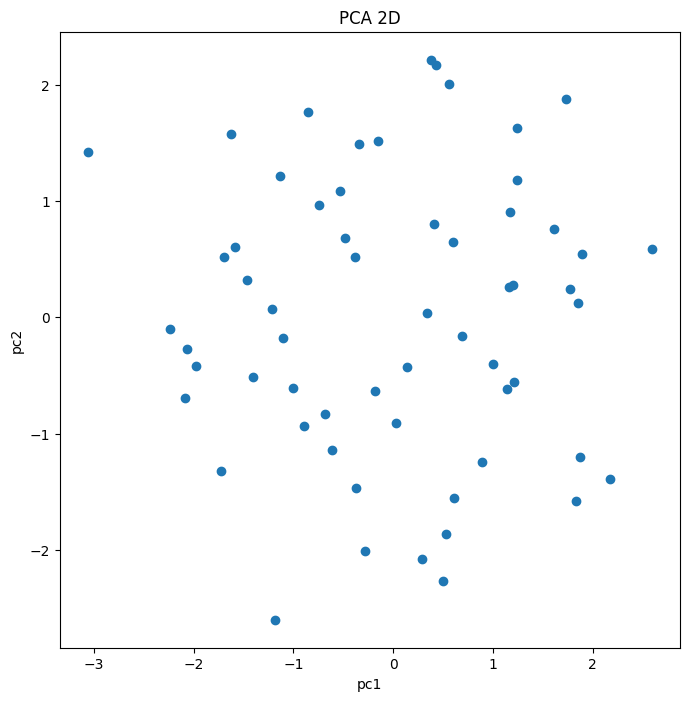

In [7]:
plt.figure(figsize=(8, 8))
plt.title('PCA 2D')
plt.scatter(x[:, 0], x[:, 1], cmap='plasma')
plt.xlabel('pc1')
plt.ylabel('pc2')
plt.show()